In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import joblib

In [14]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [15]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (918, 12)

Missing Values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [16]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)


In [17]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [18]:
df.drop_duplicates(inplace=True)

print("After Cleaning Shape:", df.shape)


After Cleaning Shape: (918, 12)


In [19]:
df = pd.get_dummies(df, drop_first=True)

print("Encoded Shape:", df.shape)

Encoded Shape: (918, 16)


In [20]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [21]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

In [26]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


Text(0.5, 1.0, 'Age Distribution')

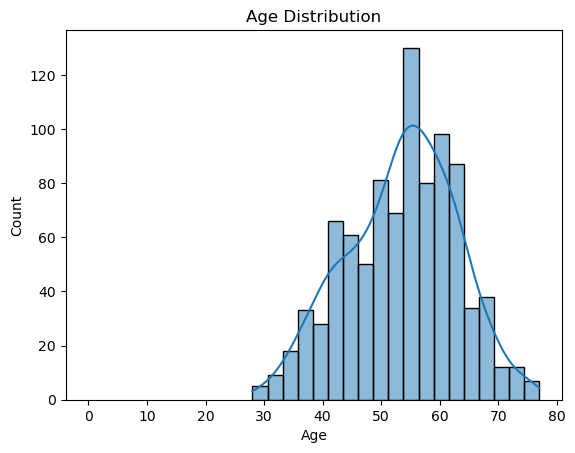

In [28]:
plt.plot(3,4,1)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")

Text(0.5, 1.0, 'Gender Distribution (Male=1)')

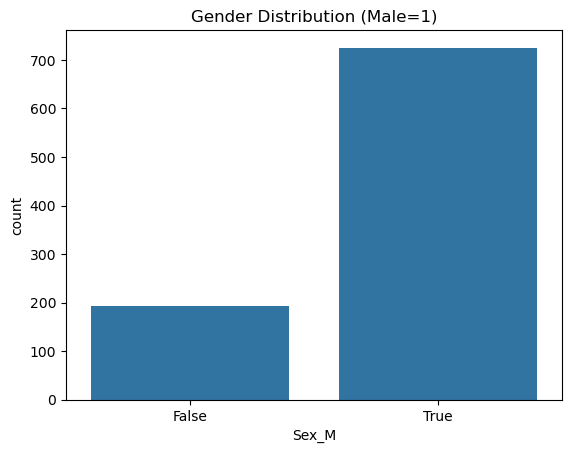

In [29]:
plt.plot(3,4,2)
sns.countplot(x=df['Sex_M'])
plt.title("Gender Distribution (Male=1)")

Text(0.5, 1.0, 'Chest Pain vs Disease')

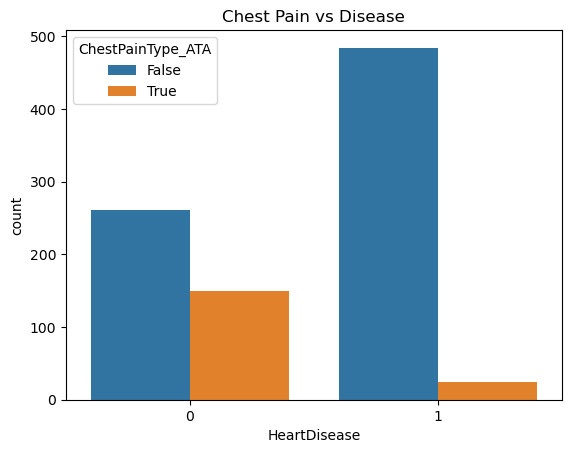

In [30]:
plt.plot(3,4,3)
sns.countplot(x=y, hue=df['ChestPainType_ATA'])
plt.title("Chest Pain vs Disease")


AttributeError

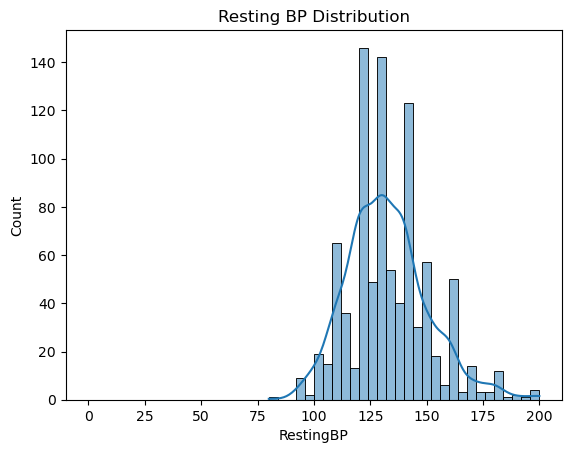

In [31]:
plt.plot(3,4,4)
sns.histplot(df['RestingBP'], kde=True)
plt.title("Resting BP Distribution")
AttributeError

Text(0.5, 1.0, 'Cholesterol Distribution')

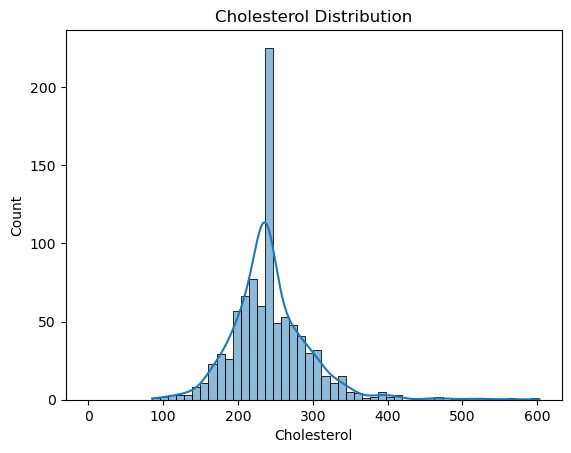

In [32]:

plt.plot(3,4,5)
sns.histplot(df['Cholesterol'], kde=True)
plt.title("Cholesterol Distribution")

Text(0.5, 1.0, 'MaxHR vs Disease')

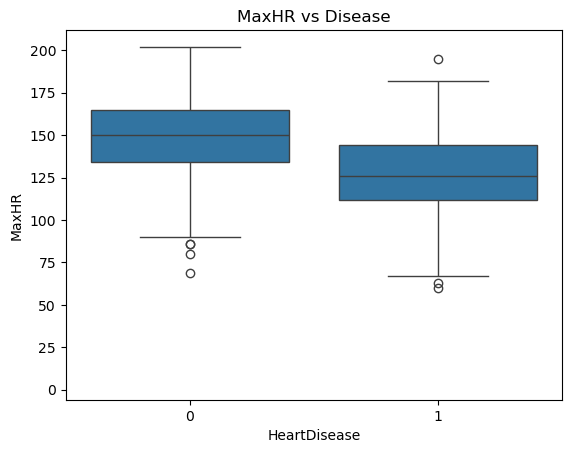

In [33]:
plt.plot(3,4,6)
sns.boxplot(x=y, y=df['MaxHR'])
plt.title("MaxHR vs Disease")

Text(0.5, 1.0, 'Oldpeak Distribution')

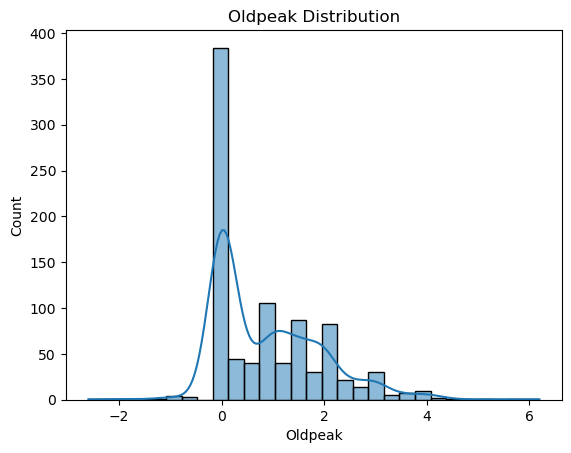

In [34]:
plt.plot(3,4,7)
sns.histplot(df['Oldpeak'], kde=True)
plt.title("Oldpeak Distribution")

Text(0.5, 1.0, 'ST Slope vs Disease')

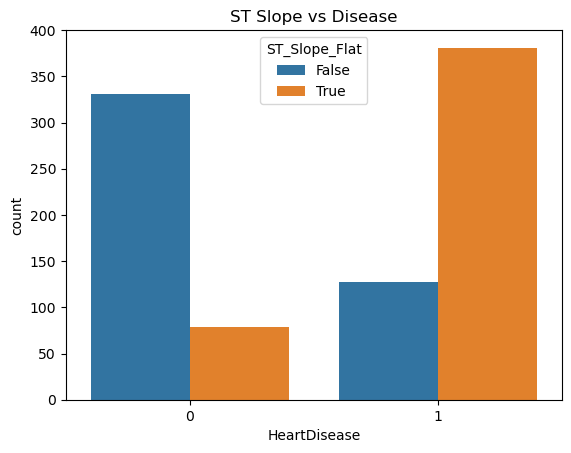

In [35]:
plt.plot(3,4,8)
sns.countplot(x=y, hue=df['ST_Slope_Flat'])
plt.title("ST Slope vs Disease")

Text(0.5, 1.0, 'FastingBS vs Disease')

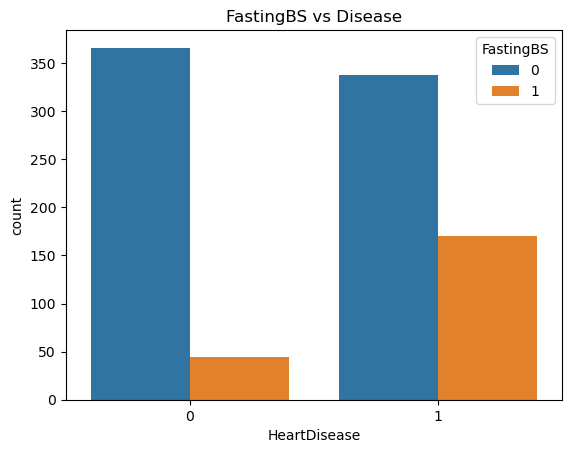

In [36]:
plt.plot(3,4,9)
sns.countplot(x=y, hue=df['FastingBS'])
plt.title("FastingBS vs Disease")

Text(0.5, 1.0, 'Correlation Heatmap')

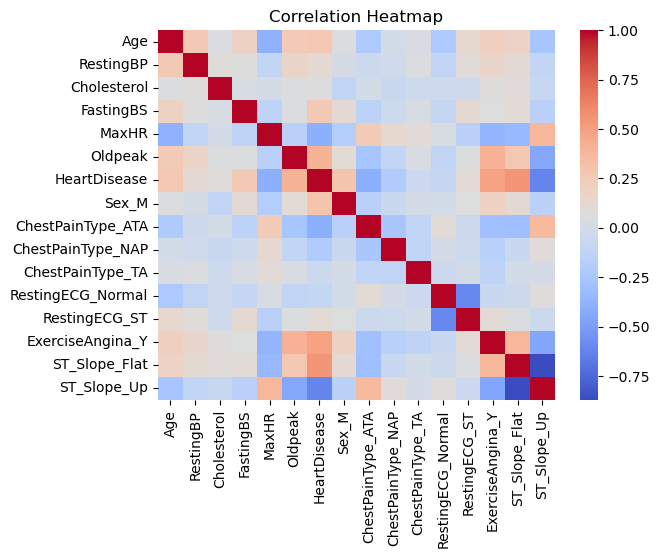

In [37]:
plt.plot(3,4,10)
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")

In [41]:
import plotly.express as px
from sklearn.decomposition import PCA

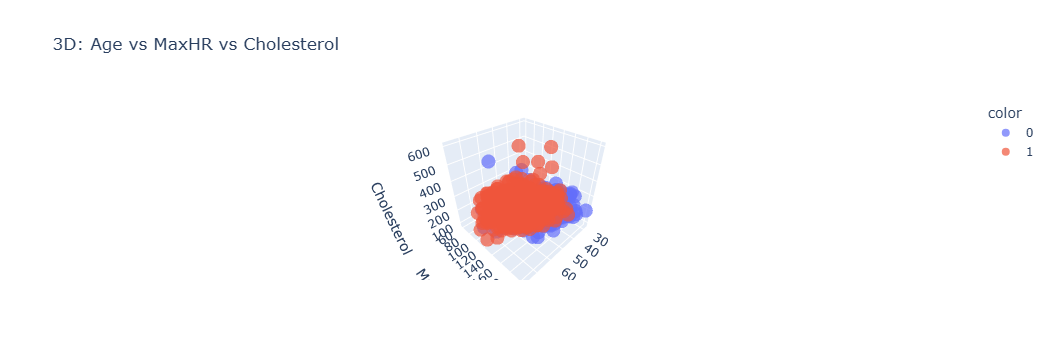

In [42]:
fig1 = px.scatter_3d(
    df,
    x='Age',
    y='MaxHR',
    z='Cholesterol',
    color=y.astype(str),
    title='3D: Age vs MaxHR vs Cholesterol',
    opacity=0.7
)

fig1.show()

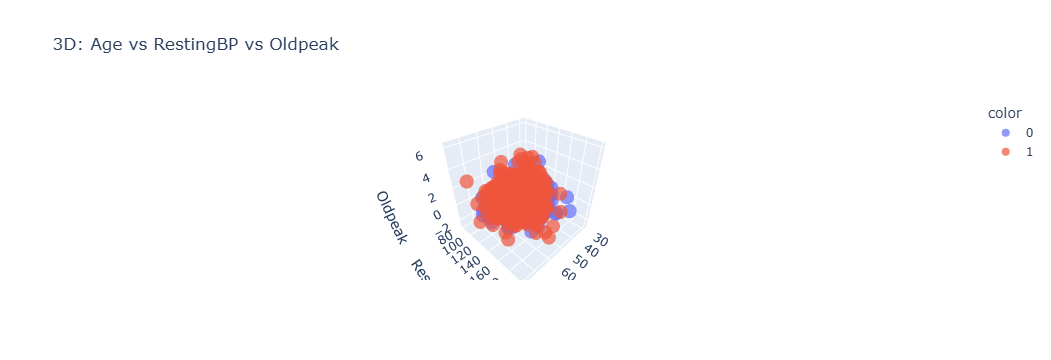

In [43]:
fig2 = px.scatter_3d(
    df,
    x='Age',
    y='RestingBP',
    z='Oldpeak',
    color=y.astype(str),
    title='3D: Age vs RestingBP vs Oldpeak',
    opacity=0.7
)

fig2.show()

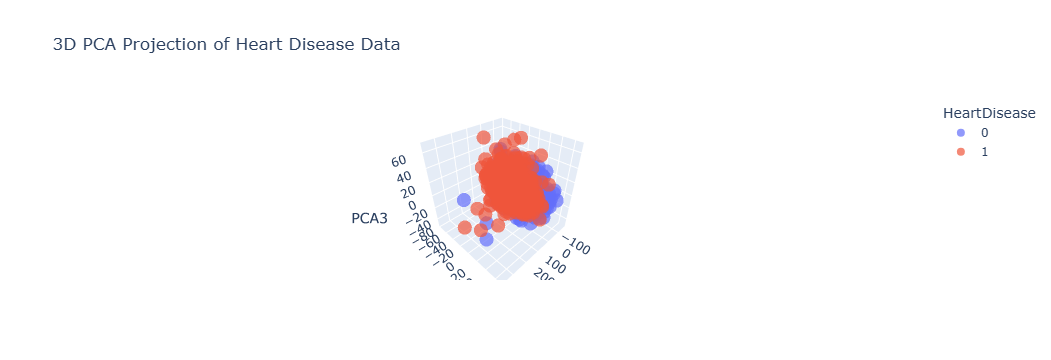

In [44]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PCA1', 'PCA2', 'PCA3']
)

pca_df['HeartDisease'] = y.values.astype(str)

fig3 = px.scatter_3d(
    pca_df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='HeartDisease',
    title='3D PCA Projection of Heart Disease Data',
    opacity=0.7
)

fig3.show()

In [45]:
importances = best_model.named_steps['model'].feature_importances_

feature_names = X.columns


In [46]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

In [47]:
importance_df = importance_df.sort_values(by='Importance', ascending=False)


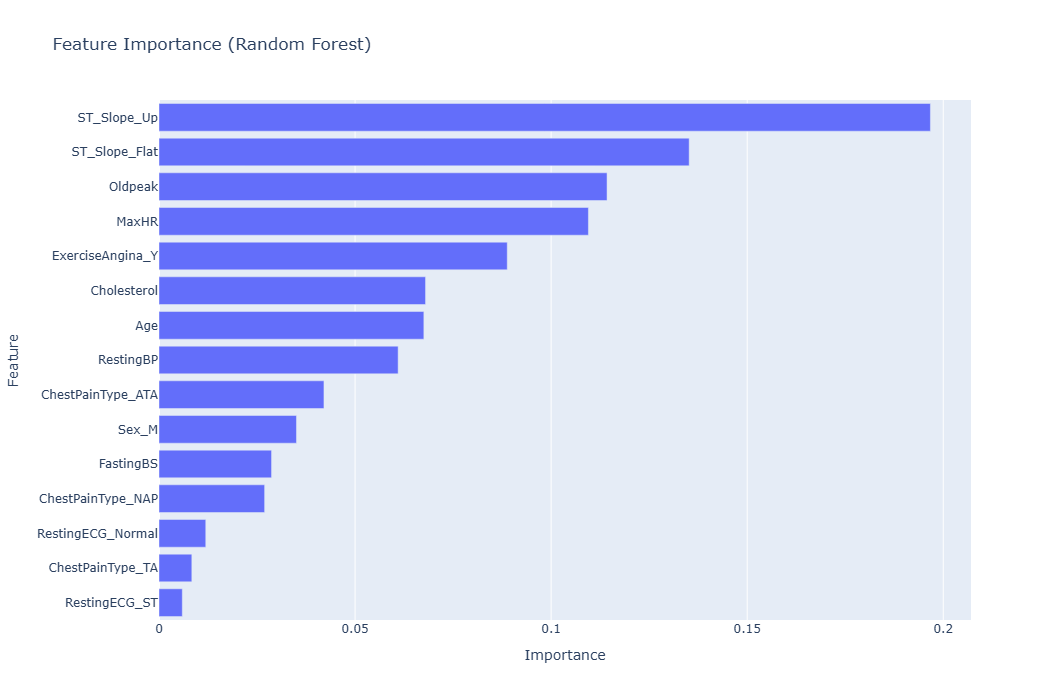

In [48]:
fig_full = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Feature Importance (Random Forest)',
    height=700
)

fig_full.update_layout(yaxis=dict(autorange="reversed"))
fig_full.show()


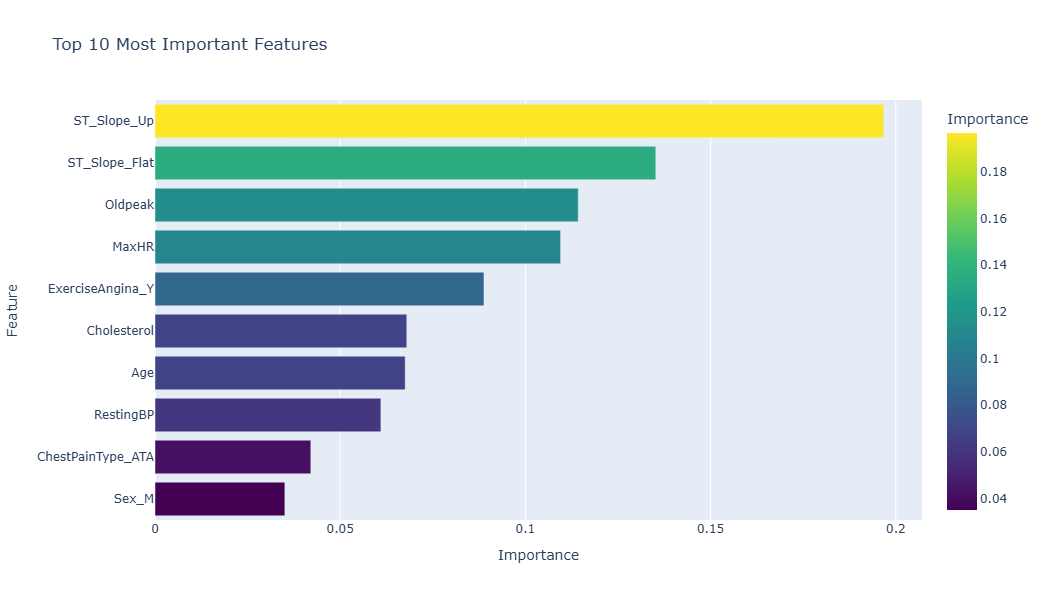

In [49]:
top10 = importance_df.head(10)

fig_top10 = px.bar(
    top10,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 10 Most Important Features',
    height=600,
    color='Importance',
    color_continuous_scale='viridis'
)

fig_top10.update_layout(yaxis=dict(autorange="reversed"))
fig_top10.show()

In [50]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8478
F1 Score: 0.8614

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.87      0.85      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



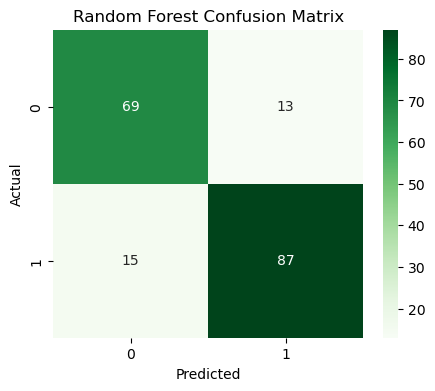

In [51]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

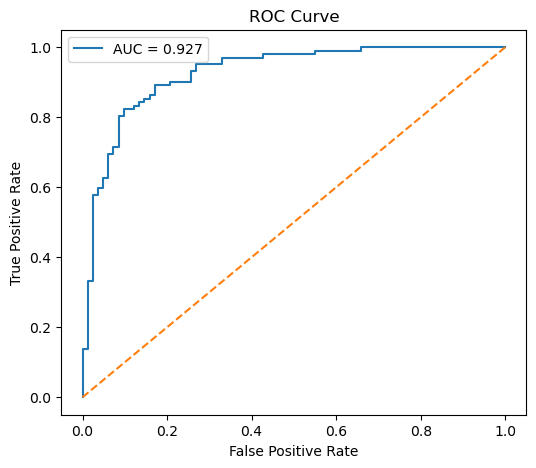

In [52]:
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [53]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [54]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)
}


In [56]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("\n==============================")
    print("Model:", name)
    print("Accuracy:", round(acc,4))
    print("F1 Score:", round(f1,4))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })


Model: Logistic Regression
Accuracy: 0.8804
F1 Score: 0.8932
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


Model: KNN
Accuracy: 0.6685
F1 Score: 0.7053
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.61      0.62        82
           1       0.70      0.72      0.71       102

    accuracy                           0.67       184
   macro avg       0.66      0.66      0.66       184
weighted avg       0.67      0.67      0.67       184


Model: Naive Bayes
Accuracy: 0.875
F1 Score: 0.8844
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        82
    

In [63]:
results_df = pd.DataFrame(results)

print(" MODEL COMPARISON TABLE")
print(results_df.sort_values(by="Accuracy", ascending=False))

 MODEL COMPARISON TABLE
                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8804    0.8932
2          Naive Bayes    0.8750    0.8844
3        Decision Tree    0.7880    0.8098
4                  SVM    0.7065    0.7404
1                  KNN    0.6685    0.7053


In [58]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print("\nBest Model Based on Accuracy:", best_model_name)


Best Model Based on Accuracy: Logistic Regression


In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib

# 🔹 Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("\n==============================")
    print("Model:", name)
    print("Accuracy:", round(acc,4))
    print("F1 Score:", round(f1,4))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1": f1
    }

# 🔹 Find Best Model
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
best_model = results[best_model_name]["model"]

print("\n🔥 BEST MODEL:", best_model_name)
print("Best Accuracy:", round(results[best_model_name]["accuracy"],4))


Model: Logistic Regression
Accuracy: 0.8913
F1 Score: 0.9029
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


Model: SVM
Accuracy: 0.8533
F1 Score: 0.8708
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83        82
           1       0.85      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


Model: KNN
Accuracy: 0.8913
F1 Score: 0.9029
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           

In [68]:
joblib.dump(best_model, "best_scaled_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("\nModel & Scaler Saved Successfully ✅")


Model & Scaler Saved Successfully ✅
